In [1]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn
import pandas as pd
import torch

from utils_pytorch import EarlyStopping, train_one_epoch, evaluate_epoch, training, print_curves, save_checkpoint, load_model, predict

In [2]:
hyperparameters = {
    'seed' : 17,
    'batch_size' : 16,
    'dropout' : 0.3,
    'learning_rate' : 1e-3,  
    'l2_lambda' : 1e-4,      
    'n_epochs' : 150,
    'patience' : 15,
    'min_delta' : 1e-4
}

In [3]:
# Fix all random seeds for full reproducibility
torch.manual_seed(hyperparameters['seed'])

# Use GPU if available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [4]:
print("Loading dataset ...")
df = pd.read_csv('/Users/irene/Library/CloudStorage/OneDrive-UNIPA/UNIPA/DIDATTICA/ESAMI BD/dataset/spotify.csv')
df['playlist_genre'].unique()

Loading dataset ...


array(['rock', 'latin', 'rap', 'edm', 'r&b', 'pop'], dtype=object)

In [5]:
label2id = {item: idx for idx, item in enumerate(df['playlist_genre'].unique())}
id2label = {idx: item for idx, item in enumerate(df['playlist_genre'].unique())}

id2label

{0: 'rock', 1: 'latin', 2: 'rap', 3: 'edm', 4: 'r&b', 5: 'pop'}

In [6]:
label_col = list(df['playlist_genre'])

features = df[['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']]

X_train, X_test, y_train, y_test = train_test_split(
    features, label_col,
    test_size=0.20,                         # Takes 20% of the data
    stratify=label_col,   # Ensures 'label' proportions are kept
    random_state=hyperparameters['seed'],                      # For reproducibility
)

# the 10% of the training set is the validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.10,      
    stratify=y_train,   
    random_state=hyperparameters['seed'],                      
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on training data only
X_val_sc = scaler.transform(X_val)   # fit on training data only
X_test_sc  = scaler.transform(X_test)    # apply same transform to test

hyperparameters['n_features']  = len(features.columns)
hyperparameters['n_classes']   = len(df.playlist_genre.unique())

print('Dataset loaded and scaled')

Dataset loaded and scaled


In [7]:
class MyDataset(Dataset):
    # Wraps a the data set in a custom PyTorch Dataset

    def __init__(self, X, y, label2id):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor([label2id[item] for item in y])

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_set = MyDataset(X_train_sc, y_train, label2id)
val_set = MyDataset(X_val_sc, y_val, label2id)
test_set = MyDataset(X_test_sc, y_test, label2id)

print(f'Split  ->  train: {len(train_set)}  |  val: {len(val_set)}  |  test: {len(test_set)}')

# Quick sanity-check: inspect one sample
x_sample, y_sample = train_set[0]
print('Features dtype/shape:', x_sample.dtype, x_sample.shape)
print('Label dtype/value   :', y_sample.dtype, y_sample.item())

Split  ->  train: 5716  |  val: 636  |  test: 1588
Features dtype/shape: torch.float32 torch.Size([12])
Label dtype/value   : torch.int64 3


In [8]:
# shuffle=True for train; no need to shuffle validation and test
train_loader = DataLoader(train_set, batch_size=hyperparameters['batch_size'], shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=hyperparameters['batch_size'], shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=hyperparameters['batch_size'], shuffle=False)

# Verify batch shape
X_batch, y_batch = next(iter(train_loader))
print('Batch features shape:', X_batch.shape)   # (BATCH_SIZE, N_FEATURES)
print('Batch labels shape  :', y_batch.shape)   # (BATCH_SIZE,)

Batch features shape: torch.Size([16, 12])
Batch labels shape  : torch.Size([16])


In [9]:
# fraction of neurons to drop during each forward pass in training

class NeuralNetwork(nn.Module):
    def __init__(self, n_features, dropout, n_classes):
        super().__init__()

        self.net = nn.Sequential(
            # --- Input -> hidden layer 1 ---
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            # --- Hidden layer 2 ---
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            # --- Output layer: raw logits, one per class ---
            nn.Linear(32, n_classes),
        )
    
    def forward(self, x):
        logits = self.net(x) # no activation function, embedded in the loss
        return logits
    
    def predict(self, x):
        logits = self.net(x)
        pred_probab = nn.LogSoftmax(dim=1)(logits) # explicity apply activation function on evalutation
        return logits, pred_probab

In [10]:
model = NeuralNetwork(hyperparameters['n_features'], hyperparameters['dropout'], hyperparameters['n_classes'])

print('=== Architecture ===' )
print(model)

print('\n=== Named parameters ===')
for name, param in model.named_parameters():
    print(f'\t{name:25s}\tshape: {list(param.shape)}\trequires_grad: {param.requires_grad}')

print('\n=== Parameter count by layer ===')
for name, module in model.named_modules():
    n = sum(p.numel() for p in module.parameters(recurse=False))
    if n > 0:   # skip containers with no own parameters
        print(f'  {name or "(root)":25s}  params: {n:,}')

=== Architecture ===
NeuralNetwork(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=6, bias=True)
  )
)

=== Named parameters ===
	net.0.weight             	shape: [64, 12]	requires_grad: True
	net.0.bias               	shape: [64]	requires_grad: True
	net.3.weight             	shape: [32, 64]	requires_grad: True
	net.3.bias               	shape: [32]	requires_grad: True
	net.6.weight             	shape: [6, 32]	requires_grad: True
	net.6.bias               	shape: [6]	requires_grad: True

=== Parameter count by layer ===
  net.0                      params: 832
  net.3                      params: 2,080
  net.6                      params: 198


In [12]:
# CrossEntropyLoss = log-softmax + negative log-likelihood; expects raw logits
criterion = nn.CrossEntropyLoss()

# weight_decay adds L2 penalty to every parameter update
optimizer = optim.Adam(model.parameters(), lr=hyperparameters['learning_rate'], weight_decay=hyperparameters['l2_lambda'])

early_stopping = EarlyStopping(patience=hyperparameters['patience'], min_delta=hyperparameters['min_delta'], checkpoint_path='best_model.pt')
print('EarlyStopping configured with patience =', early_stopping.patience)

EarlyStopping configured with patience = 15


In [13]:
history, epoch = training(model, train_loader, val_loader, criterion, optimizer, early_stopping, device, max_epochs=hyperparameters['n_epochs'])

  7%|▋         | 11/150 [00:01<00:18,  7.69it/s]

Epoch  10 | train loss: 0.0852 | val loss: 0.0803 | val acc: 0.5079


 14%|█▍        | 21/150 [00:02<00:15,  8.11it/s]

Epoch  20 | train loss: 0.0823 | val loss: 0.0786 | val acc: 0.5314


 21%|██        | 31/150 [00:03<00:15,  7.91it/s]

...

Epoch  50 | train loss: 0.0781 | val loss: 0.0757 | val acc: 0.5189


 41%|████      | 61/150 [00:07<00:11,  7.53it/s]

Epoch  60 | train loss: 0.0778 | val loss: 0.0766 | val acc: 0.5314


 41%|████      | 61/150 [00:08<00:11,  7.60it/s]


Early stopping triggered at epoch 62.
Best val loss: 0.0755

Training complete.


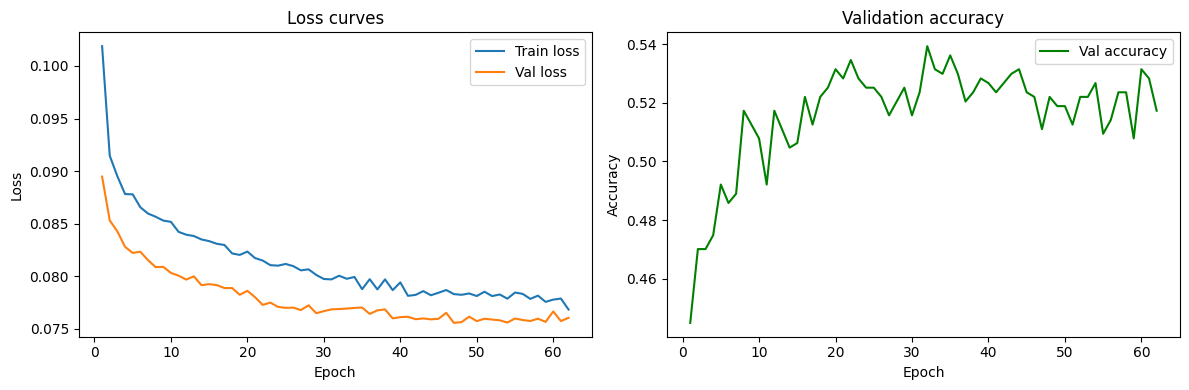

In [14]:
print_curves(history)

In [15]:
model.load_state_dict(torch.load('best_model.pt', map_location=device))

test_loss, test_acc = evaluate_epoch(model, test_loader, criterion, device)
print(f'Test loss: {test_loss:.4f}  |  Test accuracy: {test_acc:.4f}')

Test loss: 0.0785  |  Test accuracy: 0.5271


In [16]:
save_checkpoint(epoch, model, optimizer, history['val_loss'], 'full_checkpoint.pt')

In [17]:
model_loaded = NeuralNetwork(hyperparameters['n_features'], hyperparameters['dropout'], hyperparameters['n_classes']).to(device)
optimizer_loaded = optim.Adam(model.parameters(), lr=hyperparameters['learning_rate'], weight_decay=hyperparameters['l2_lambda'])

model_loaded, optimizer_loaded, start_epoch, val_loss = load_model('full_checkpoint.pt', model_loaded, optimizer_loaded)

print(f'Checkpoint from epoch {epoch-1} loaded. '
      f'Val loss was {val_loss[-1]:.4f}.')

Checkpoint from epoch 61 loaded. Val loss was 0.0760.


In [18]:
y_test, y_preds, y_score = predict(model_loaded, test_loader, device)

In [19]:
print(classification_report(y_test, y_preds, target_names=label2id.keys()))

              precision    recall  f1-score   support

        rock       0.61      0.67      0.64       241
       latin       0.49      0.28      0.36       232
         rap       0.54      0.68      0.60       303
         edm       0.64      0.70      0.67       273
         r&b       0.43      0.45      0.44       252
         pop       0.40      0.34      0.37       287

    accuracy                           0.53      1588
   macro avg       0.52      0.52      0.51      1588
weighted avg       0.52      0.53      0.52      1588



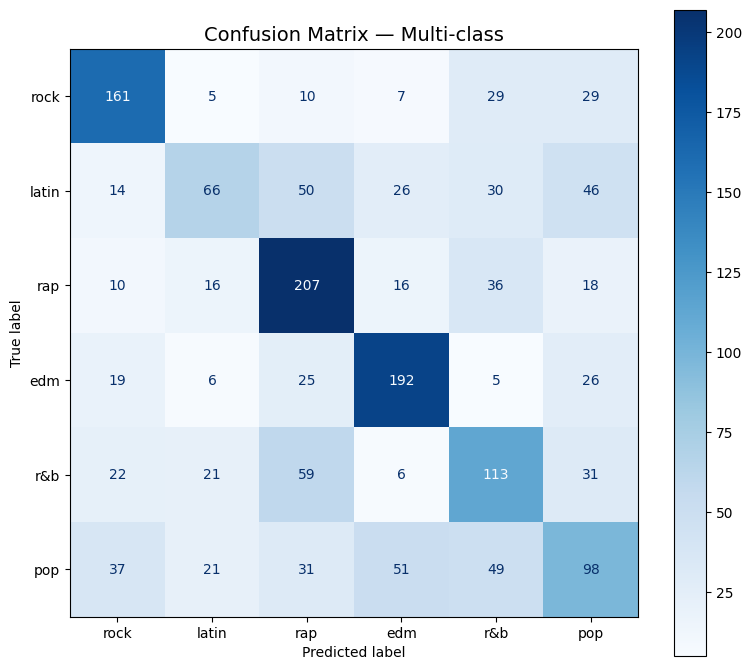

In [20]:
fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_preds,
    display_labels=label2id.keys(),
    cmap='Blues',
    ax=ax
)

plt.title('Confusion Matrix — Multi-class', fontsize=14)
plt.tight_layout()
plt.show()

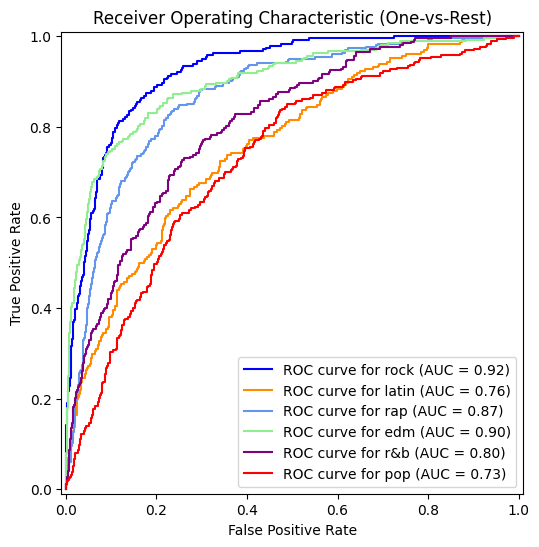

In [21]:
label_binarizer = LabelBinarizer().fit([label2id[item] for item in y_train])
y_onehot_test = label_binarizer.transform(y_test)
n_classes = len(label_binarizer.classes_)

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))

colors = ['blue', 'darkorange', 'cornflowerblue', 'lightgreen', 'purple', 'red']
for class_id, color in zip(range(n_classes), colors):
    RocCurveDisplay.from_predictions(
        y_onehot_test[:, class_id],
        y_score[:, class_id],
        name=f"ROC curve for {id2label[class_id]}",
        curve_kwargs=dict(color=color),
        ax=ax,
    )

ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", 
       title="Receiver Operating Characteristic (One-vs-Rest)")
plt.show()